# Postsynaptic projections 

In [ ]:
import pandas as pd
import numpy as np
import pdb
import seaborn as sns
from matplotlib import pyplot as plt
import os
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "browser"

In [2]:
# Load dataset 

#Change to directory containing .csv file
file_dir = "/Users/jieunyum/Desktop/Y2/NEUR0024/extension_workshops/BiasedConnectivityVS/Wee_2020_TRIO"
os.chdir(file_dir)

df = pd.read_csv("coronal_CTBLabelled_dataset.csv")

#Filter dataframe by projection type 
df_subset_PFC = df[df.Projection == 'PFC']
df_subset_NAc = df[df.Projection == 'NAc']
df_subset_LH = df[df.Projection == 'LH']



### 1 Spatial distribution 

Results: Occupy spatially distinct locations within vS - PFC located more anterior, LH more posterior, NAc spread across entire range 


Text(0.5, 1.0, 'DV')

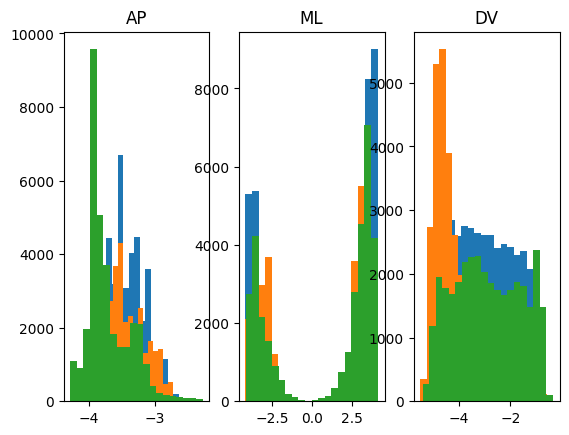

In [26]:
# Plot histograms  
fig, ax = plt.subplots(1, 3) 
binsize=20

# AP axis 
ax[0].hist(df_subset_PFC['AP'], label='PFC', bins=binsize)
ax[0].hist(df_subset_NAc['AP'], label='NAc', bins=binsize)
ax[0].hist(df_subset_LH['AP'], label='LH', bins=binsize)
ax[0].set_title("AP")

# ML axis 
ax[1].hist(df_subset_PFC['ML'], label='PFC', bins=binsize)
ax[1].hist(df_subset_NAc['ML'], label='NAc', bins=binsize)
ax[1].hist(df_subset_LH['ML'], label='LH', bins=binsize)
ax[1].set_title("ML")

# DV axis 
ax[2].hist(df_subset_PFC['DV'], label='PFC', bins=binsize)
ax[2].hist(df_subset_NAc['DV'], label='NAc', bins=binsize)
ax[2].hist(df_subset_LH['DV'], label='LH', bins=binsize)
ax[2].set_title("DV")



In [15]:
# 3D plot, grouped by projection type 

fig = px.scatter_3d(df, x="AP", y="ML", z="DV", color='Projection', opacity=0.5)

fig["layout"].update(width=1200, height=800, autosize=False)
fig.update_traces(marker_size=2)

fig.show()


### 2 Correlation analysis 

Results: Covaried across all 3 axes (AP, ML, DV), but vary mostly dramatically with AP position 
- spatial position along AP most predcitive of output target 

Reason for distribution across AP axis: 
- variance in AP well explained by PD (proximal-distal) gradient of neurons in pyramidal cell layer of VS
- projection type varies most along PD compared with DS (depp-superficial) and DS (dorsal-ventral) 


In [20]:
from scipy.stats import pointbiserialr

In [76]:
# Correlational analysis for each projection 

corr_analysis = []

for projection in ["PFC", "NAc", "LH"]:
    for animal in df["animal"].unique():
        df_animal = df[df["animal"] == animal].copy()

        # make binary projection column
        df_animal[f"is_{projection}"] = (df_animal["Projection"] == projection).astype(int)

        for axis in ["AP", "ML", "DV"]:
            # keep only needed columns and drop NaNs
            temp = df_animal[[f"is_{projection}", axis]].dropna()

            # skip if binary variable has no variation
            if temp[f"is_{projection}"].nunique() < 2:
                continue

            # skip if axis has no variation
            if temp[axis].nunique() < 2:
                continue

            r, p = pointbiserialr(temp[f"is_{projection}"], temp[axis])

            corr_analysis.append({
                "Projection": projection,
                "Animal": animal,
                "Axis": axis,
                "r": r,
                "abs_r": abs(r),
                "p": p
            })

df_corr = pd.DataFrame(corr_analysis)

In [ ]:
# Average across all axes 
df_mean = (
    df_corr
    .groupby(["Projection", "Axis"])["abs_r"]
    .mean()
    .reset_index()
)

df_sem = (
    df_corr
    .groupby(["Projection", "Axis"])["abs_r"]
    .sem()
    .reset_index()
)

df_stats = df_mean.merge(
    df_sem,
    on=["Projection", "Axis"],
    suffixes=("_mean", "_sem")
)

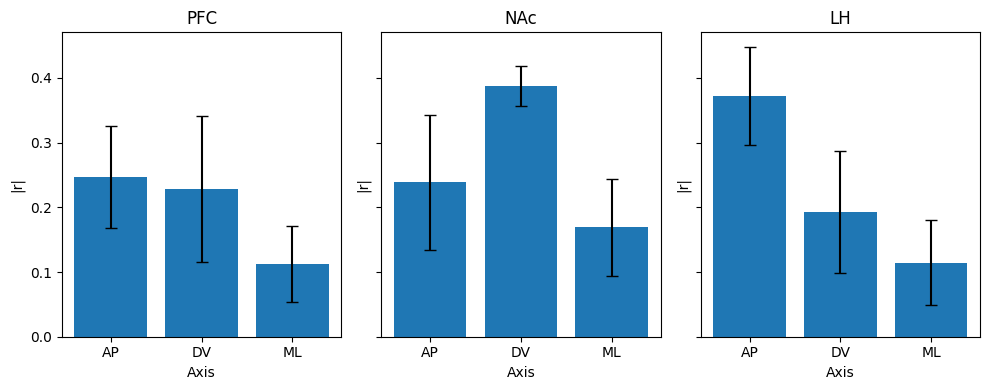

In [ ]:
# Plot 
fig, ax = plt.subplots(1, 3, figsize=(10, 4), sharey=True)

for i, projection in enumerate(["PFC", "NAc", "LH"]):
    d = df_stats[df_stats["Projection"] == projection]

    ax[i].bar(
        d["Axis"],
        d["abs_r_mean"],
        yerr=d["abs_r_sem"],
        capsize=4
    )
    ax[i].set_title(projection)
    ax[i].set_xlabel("Axis")
    ax[i].set_ylabel("|r|")

plt.tight_layout()
plt.show()


### 3 Machine learning 

#### 3.1 Train and Test data 

In [78]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import accuracy_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


In [68]:
# Prepare data 
df_model = df.dropna().copy()

# Predictors and target
X = df_model[["AP", "ML", "DV"]]
y = df_model["Projection"]

# Stratify so class proportions are preserved
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0,
    stratify=y
)

print("Train size:", len(X_train))
print("Test size:", len(X_test))


Train size: 86632
Test size: 21659


#### 3.2 Logistic Regression 
Which axis predicts projection? 

In [70]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

full_model = make_pipeline(
    StandardScaler(),
    LogisticRegressionCV(
        cv=cv,
        max_iter=5000,
        random_state=42,
        scoring="accuracy"
    )
)

full_model.fit(X_train, y_train)

# Test accuracy on unseen data
y_pred_full = full_model.predict(X_test)
full_test_acc = accuracy_score(y_test, y_pred_full)

print(f"Full model test accuracy: {full_test_acc:.3f}")


/Users/jieunyum/Desktop/Y2/NEUR0024/extension_workshops/tutorial-env2/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/jieunyum/Desktop/Y2/NEUR0024/extension_workshops/tutorial-env2/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of

Full model test accuracy: 0.583


In [75]:
axes = ["AP", "ML", "DV"]
results = []

for axis_to_remove in axes:
    remaining_axes = [ax for ax in axes if ax != axis_to_remove]

    X_train_reduced = X_train[remaining_axes]
    X_test_reduced = X_test[remaining_axes]

    reduced_model = make_pipeline(
        StandardScaler(),
        LogisticRegressionCV(
            cv=cv,
            max_iter=5000,
            random_state=42,
            scoring="accuracy"
        )
    )

    reduced_model.fit(X_train_reduced, y_train)

    y_pred_reduced = reduced_model.predict(X_test_reduced)
    reduced_test_acc = accuracy_score(y_test, y_pred_reduced)

    delta_acc = (full_test_acc - reduced_test_acc)/full_test_acc * 100 

    results.append({
        "removed_axis": axis_to_remove,
        "full_test_accuracy": full_test_acc,
        "reduced_test_accuracy": reduced_test_acc,
        "delta_accuracy": delta_acc
    })

df_results = pd.DataFrame(results)
print(df_results)

/Users/jieunyum/Desktop/Y2/NEUR0024/extension_workshops/tutorial-env2/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/jieunyum/Desktop/Y2/NEUR0024/extension_workshops/tutorial-env2/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simplified in scikit-learn 1.10 to remove redundancy. Set`use_legacy_attributes=False` to enable the new behavior now, or set it to `True` to silence this warning during the transition period while keeping the deprecated behavior for the time being. The default value of use_legacy_attributes will change from True to False in scikit-learn 1.10. See the docstring of

  removed_axis  full_test_accuracy  reduced_test_accuracy  delta_accuracy
0           AP            0.583406               0.475968       18.415638
1           ML            0.583406               0.583037        0.063311
2           DV            0.583406               0.508518       12.836341


#### 3.3 Linear Discriminant Analysis 
What direction in space best separates projection? 

LDA is a dimensionality reduction method that identifies the subspace which maximizes the ratio of the between-class over the within-class variability. 
used to unbiasedly find virtual plane that best separates the 3 populations of projection neurons 

Results: Highly overlapping spatial distribution 
- compared to dorsal subiculumwhere there is sharp PD border separating distinct projection populations 
- VS organised as a gradient 


In [ ]:
lda = LinearDiscriminantAnalysis()

lda.fit(X_train, y_train)

X_test_lda = lda.transform(X_test)


print(X_test_lda[:,0])
print(X_test_lda[:,1])

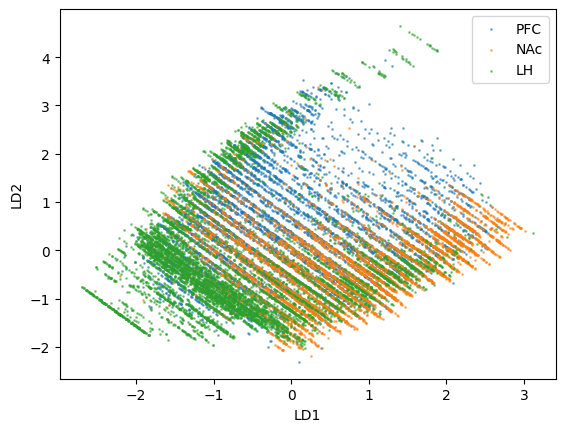

In [87]:
for proj in ["PFC", "NAc", "LH"]:
    mask = y_test == proj
    plt.scatter(
        X_test_lda[mask,0],
        X_test_lda[mask,1],
        label=proj,
        alpha=0.5, 
        s = 1
    )

plt.xlabel("LD1")
plt.ylabel("LD2")
plt.legend()
plt.show()

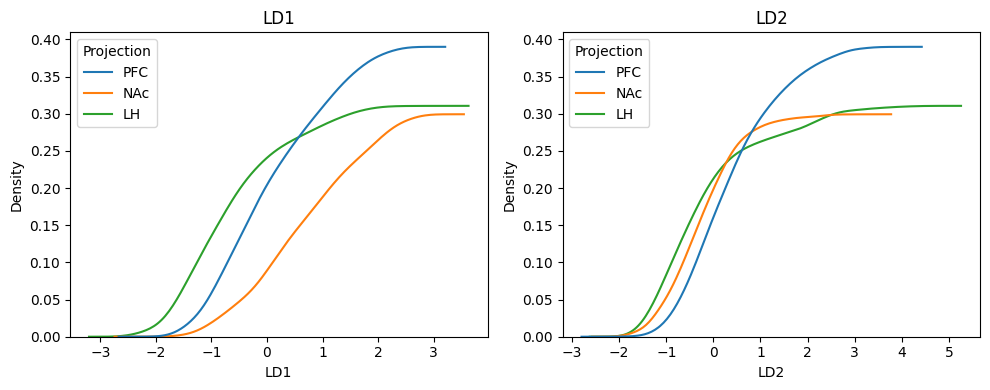

In [ ]:
df_lda = pd.DataFrame({
    "LD1": X_test_lda[:, 0],
    "LD2": X_test_lda[:, 1],
    "Projection": y_test.values
})


fig, ax = plt.subplots(1, 2, figsize=(10,4))

sns.kdeplot(
    data=df_lda,
    x="LD1",
    hue="Projection",
    cumulative=True,
    ax=ax[0]
)

sns.kdeplot(
    data=df_lda,
    x="LD2",
    hue="Projection",
    cumulative=True,
    ax=ax[1]
)

ax[0].set_title("LD1")
ax[1].set_title("LD2")

plt.tight_layout()